# 🏠 House Price Prediction: End-to-End Data Science, Machine Learning and Streamlit App Demo

## Live demo project for students

Welcome to a complete beginner-friendly but exciting **end-to-end Data Science and Machine Learning project**.

In this notebook, we will behave like a small analytics/product team building a practical solution for a real business problem:

> **Can we build a model that estimates the selling price of a house from its features, then turn that model into a simple web app?**

This project takes us through the full workflow:

1. Business understanding  
2. Dataset loading  
3. Data inspection  
4. Data cleaning  
5. Exploratory Data Analysis  
6. Data visualization  
7. Feature engineering  
8. Machine learning model training  
9. Model evaluation  
10. Model interpretation  
11. Saving the model  
12. Building a Streamlit web app  
13. Preparing for deployment  

---

## Product idea

### Product name: **HomeValue AI**

A simple decision-support tool that helps property agents, homeowners, and analysts estimate a likely house sale price from important property features.

This is not a replacement for a professional property valuation. It is a learning project and prototype showing how data can support decision-making.

## 📌 Dataset

We will use the Kaggle competition dataset:

**House Prices - Advanced Regression Techniques**

🔗 **Dataset link:** https://www.kaggle.com/competitions/house-prices-advanced-regression-techniques/data?select=train.csv

Main files used:

- `train.csv` — training data with house features and the target column `SalePrice`
- `test.csv` — optional test data for Kaggle submission
- `sample_submission.csv` — optional sample format for competition submission
- `data_description.txt` — explains the dataset columns

### What students should do before class

1. Go to Kaggle.
2. Search for **House Prices - Advanced Regression Techniques**

🔗 **Dataset link:** https://www.kaggle.com/competitions/house-prices-advanced-regression-techniques/data?select=train.csv.
3. Download the dataset.
4. Upload `train.csv` into this notebook when asked.

This notebook also contains a small fallback demo dataset so the class can still run if the Kaggle file is not available yet.

In [33]:
# Dataset link for students
KAGGLE_DATASET_URL = "https://www.kaggle.com/competitions/house-prices-advanced-regression-techniques/data?select=train.csv"
print("Download train.csv from Kaggle here:")
print(KAGGLE_DATASET_URL)


Download train.csv from Kaggle here:
https://www.kaggle.com/competitions/house-prices-advanced-regression-techniques/data?select=train.csv


# 1. Business Understanding

Before writing code, we define the business problem clearly.

## Business problem

Property professionals often need a quick estimate of a house's likely selling price.

A data science solution can help by learning patterns from previous house sales.

## Machine learning task

This is a **regression problem** because the target we want to predict is a numerical value:

`SalePrice`

## Possible users

- Real estate agents
- Property developers
- Homeowners
- Mortgage or lending analysts
- Data science students building a portfolio project

## Business questions

1. Which features appear to influence house prices?
2. Are bigger houses always more expensive?
3. Do quality ratings matter?
4. Does neighborhood affect sale price?
5. Can we train a model to estimate the sale price?
6. Can we turn the model into a simple web app?

# 2. Import Libraries

We start by importing the tools we need.

Run this cell first.

In [34]:
# Core libraries
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Saving model files
import joblib

print("Libraries imported successfully ✅")

Libraries imported successfully ✅


# 3. Load the Dataset

This cell tries to load the Kaggle dataset in a few possible ways:

1. Kaggle Notebook path  
2. Local / Colab uploaded file called `train.csv`  
3. Google Colab file upload  
4. Small fallback dataset for class demonstration  

For the best demo, use the real Kaggle `train.csv`.

In [35]:
def create_fallback_housing_data():
    """Small fallback dataset so the notebook can run during a live demo."""
    np.random.seed(42)
    n = 300

    neighborhoods = ["CollgCr", "Veenker", "Crawfor", "NoRidge", "Mitchel", "Somerst", "OldTown"]
    house_styles = ["1Story", "2Story", "1.5Fin", "SLvl"]
    quality_labels = ["TA", "Gd", "Ex", "Fa"]
    garage_types = ["Attchd", "Detchd", "BuiltIn", "None"]
    sale_conditions = ["Normal", "Abnorml", "Partial", "Family"]

    data = pd.DataFrame({
        "Id": range(1, n + 1),
        "OverallQual": np.random.randint(3, 10, n),
        "GrLivArea": np.random.randint(700, 3500, n),
        "GarageCars": np.random.randint(0, 4, n),
        "GarageArea": np.random.randint(0, 900, n),
        "TotalBsmtSF": np.random.randint(0, 2000, n),
        "1stFlrSF": np.random.randint(500, 2400, n),
        "FullBath": np.random.randint(1, 4, n),
        "TotRmsAbvGrd": np.random.randint(4, 12, n),
        "YearBuilt": np.random.randint(1950, 2011, n),
        "YearRemodAdd": np.random.randint(1970, 2011, n),
        "LotArea": np.random.randint(2500, 20000, n),
        "Neighborhood": np.random.choice(neighborhoods, n),
        "HouseStyle": np.random.choice(house_styles, n),
        "ExterQual": np.random.choice(quality_labels, n, p=[0.45, 0.35, 0.10, 0.10]),
        "KitchenQual": np.random.choice(quality_labels, n, p=[0.45, 0.35, 0.10, 0.10]),
        "BsmtQual": np.random.choice(quality_labels + ["None"], n),
        "GarageType": np.random.choice(garage_types, n),
        "SaleCondition": np.random.choice(sale_conditions, n),
    })

    neighborhood_bonus = data["Neighborhood"].map({
        "NoRidge": 60000, "Somerst": 35000, "Veenker": 30000,
        "Crawfor": 20000, "CollgCr": 15000, "Mitchel": 5000, "OldTown": -5000
    })

    quality_bonus = data["OverallQual"] * 22000
    area_bonus = data["GrLivArea"] * 55
    garage_bonus = data["GarageCars"] * 12000
    basement_bonus = data["TotalBsmtSF"] * 25
    age_penalty = (2026 - data["YearBuilt"]) * 550
    noise = np.random.normal(0, 25000, n)

    data["SalePrice"] = (
        35000 + quality_bonus + area_bonus + garage_bonus +
        basement_bonus + neighborhood_bonus - age_penalty + noise
    ).round(0)

    data["SalePrice"] = data["SalePrice"].clip(lower=50000)
    return data


def load_housing_data():
    """Load Kaggle train.csv when available, otherwise use fallback demo data."""
    possible_paths = [
        "C:/Users/OITSILN/Downloads/train.csv",
        "train.csv",
        "/content/train.csv",
        "./data/train.csv"
    ]

    for path in possible_paths:
        if os.path.exists(path):
            print(f"Loaded dataset from: {path}")
            return pd.read_csv(path), "kaggle"

    try:
        from google.colab import files
        print("No train.csv found. Please upload Kaggle train.csv now.")
        uploaded = files.upload()
        if "train.csv" in uploaded:
            print("Uploaded train.csv successfully.")
            return pd.read_csv("train.csv"), "kaggle_uploaded"
    except Exception:
        pass

    print("Kaggle train.csv not found. Using fallback classroom dataset for demo.")
    return create_fallback_housing_data(), "fallback"


df, data_source = load_housing_data()

print("Data source:", data_source)
print("Dataset shape:", df.shape)
df.head()

Loaded dataset from: train.csv
Data source: kaggle
Dataset shape: (1460, 81)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


# 4. Inspect the Data

Before cleaning or modelling, we inspect the dataset.

Key questions:

- How many rows and columns are there?
- What columns are available?
- What is the target column?
- Are there missing values?
- What data types do we have?

In [36]:
print("Shape:", df.shape)
print("First 10 columns:")
print(df.columns[:10].tolist())

print("Dataset information:")
df.info()

Shape: (1460, 81)
First 10 columns:
['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities']
Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition

In [37]:
# Summary statistics for numerical columns
df.describe().T.head(20)

,count,mean,std,min,25%,50%,75%,max
Id,1460.0,730.500000,421.610009,1.0,365.75,730.5,1095.25,1460.0
MSSubClass,1460.0,56.897260,42.300571,20.0,20.00,50.0,70.00,190.0
LotFrontage,1201.0,70.049958,24.284752,21.0,59.00,69.0,80.00,313.0
LotArea,1460.0,10516.828082,9981.264932,1300.0,7553.50,9478.5,11601.50,215245.0
OverallQual,1460.0,6.099315,1.382997,1.0,5.00,6.0,7.00,10.0
OverallCond,1460.0,5.575342,1.112799,1.0,5.00,5.0,6.00,9.0
YearBuilt,1460.0,1971.267808,30.202904,1872.0,1954.00,1973.0,2000.00,2010.0
YearRemodAdd,1460.0,1984.865753,20.645407,1950.0,1967.00,1994.0,2004.00,2010.0
MasVnrArea,1452.0,103.685262,181.066207,0.0,0.00,0.0,166.00,1600.0
BsmtFinSF1,1460.0,443.639726,456.098091,0.0,0.00,383.5,712.25,5644.0


In [38]:
# Check if the target column exists
target = "SalePrice"

if target in df.columns:
    print("Target column found ✅")
    print(df[target].describe())
else:
    print("Target column not found ❌")

Target column found ✅
count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64


# 5. Missing Values

Real-world datasets often contain missing values.

In this section, we identify which columns have missing values.

Later, our machine learning pipeline will handle missing values automatically using imputers.

In [39]:
missing = df.isna().sum().sort_values(ascending=False)
missing_percent = (df.isna().mean() * 100).sort_values(ascending=False)

missing_report = pd.DataFrame({
    "missing_count": missing,
    "missing_percent": missing_percent.round(2)
})

missing_report[missing_report["missing_count"] > 0].head(20)

,missing_count,missing_percent
PoolQC,1453,99.52
MiscFeature,1406,96.30
Alley,1369,93.77
Fence,1179,80.75
MasVnrType,872,59.73
FireplaceQu,690,47.26
LotFrontage,259,17.74
GarageQual,81,5.55
GarageFinish,81,5.55
GarageType,81,5.55


# 6. Exploratory Data Analysis

EDA helps us understand the data before modelling.

We will look at:

- distribution of house prices
- relationship between house size and price
- relationship between quality and price
- neighborhood price differences
- correlations between numeric features

## 6.1 Distribution of SalePrice

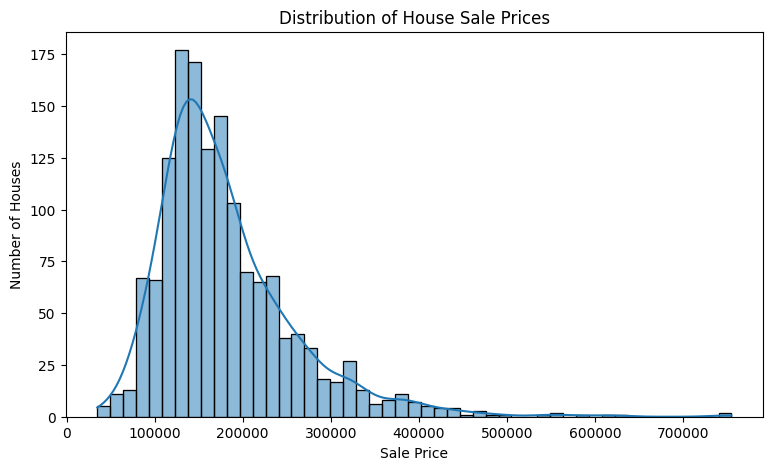

Average sale price: 180921.2
Median sale price: 163000.0


In [40]:
plt.figure(figsize=(9, 5))
sns.histplot(df["SalePrice"], kde=True)
plt.title("Distribution of House Sale Prices")
plt.xlabel("Sale Price")
plt.ylabel("Number of Houses")
plt.show()

print("Average sale price:", round(df["SalePrice"].mean(), 2))
print("Median sale price:", round(df["SalePrice"].median(), 2))

## 6.2 House Size vs Sale Price

`GrLivArea` means above-ground living area.

We expect larger houses to often sell for higher prices, but the relationship will not be perfect.

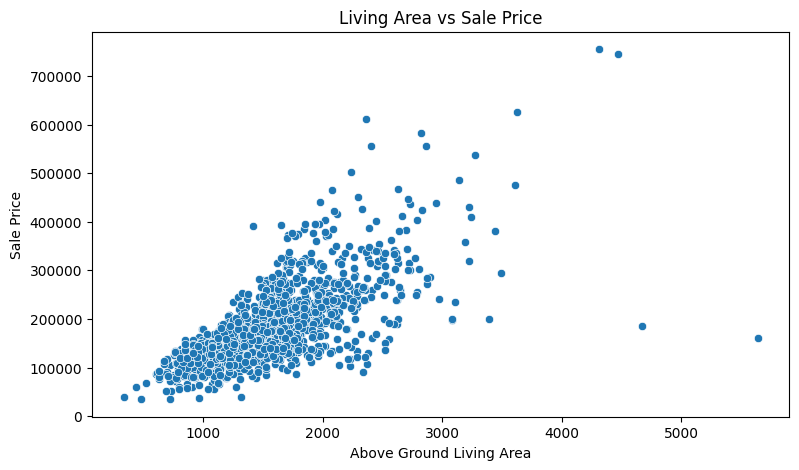

In [41]:
if "GrLivArea" in df.columns:
    plt.figure(figsize=(9, 5))
    sns.scatterplot(data=df, x="GrLivArea", y="SalePrice")
    plt.title("Living Area vs Sale Price")
    plt.xlabel("Above Ground Living Area")
    plt.ylabel("Sale Price")
    plt.show()
else:
    print("GrLivArea column not available in this dataset.")

## 6.3 Overall Quality vs Sale Price

`OverallQual` is usually one of the strongest features in this dataset.

It represents the overall material and finish quality of the house.

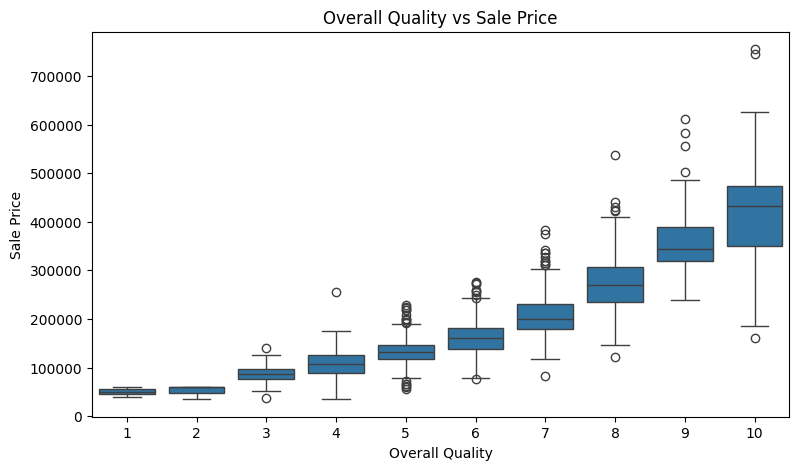

In [42]:
if "OverallQual" in df.columns:
    plt.figure(figsize=(9, 5))
    sns.boxplot(data=df, x="OverallQual", y="SalePrice")
    plt.title("Overall Quality vs Sale Price")
    plt.xlabel("Overall Quality")
    plt.ylabel("Sale Price")
    plt.show()
else:
    print("OverallQual column not available in this dataset.")

## 6.4 Neighborhood and Sale Price

Location often matters in housing prices.

Here we compare median sale price by neighborhood.

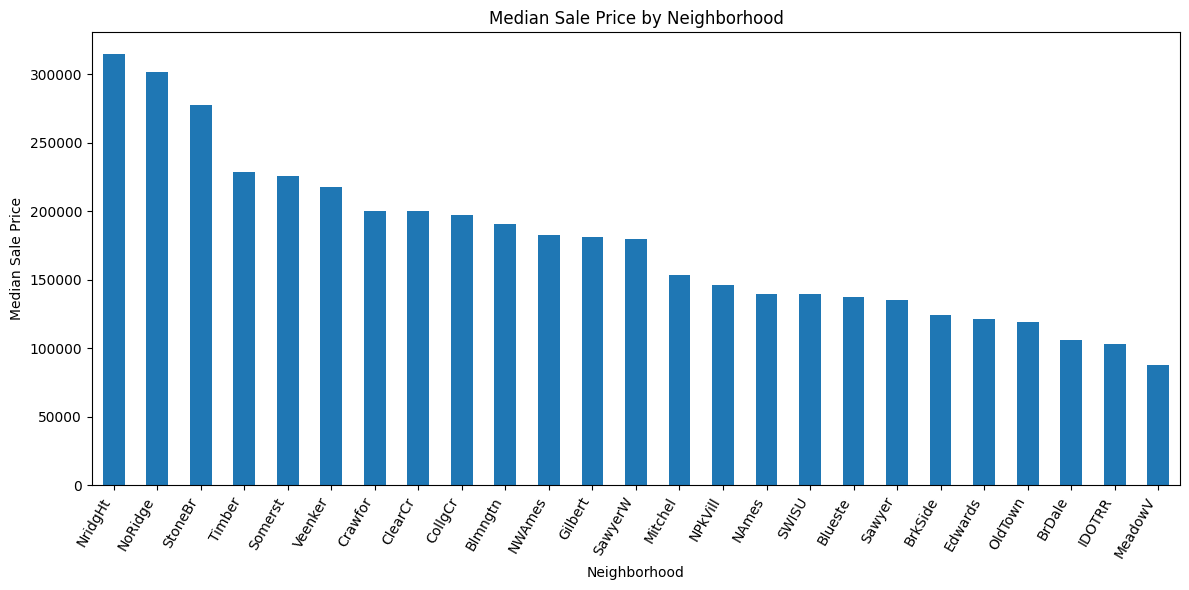

,median_sale_price
Neighborhood,
NridgHt,315000.0
NoRidge,301500.0
StoneBr,278000.0
Timber,228475.0
Somerst,225500.0
Veenker,218000.0
Crawfor,200624.0
ClearCr,200250.0
CollgCr,197200.0


In [43]:
if "Neighborhood" in df.columns:
    neighborhood_prices = (
        df.groupby("Neighborhood")["SalePrice"]
        .median()
        .sort_values(ascending=False)
    )

    plt.figure(figsize=(12, 6))
    neighborhood_prices.plot(kind="bar")
    plt.title("Median Sale Price by Neighborhood")
    plt.xlabel("Neighborhood")
    plt.ylabel("Median Sale Price")
    plt.xticks(rotation=60, ha="right")
    plt.tight_layout()
    plt.show()

    display(neighborhood_prices.head(10).to_frame("median_sale_price"))
else:
    print("Neighborhood column not available in this dataset.")

## 6.5 Correlation Heatmap

Correlation shows how strongly numeric columns move together.

A positive correlation with `SalePrice` suggests that as the feature increases, sale price often increases too.

Correlation does not prove causation, but it is useful for exploration.

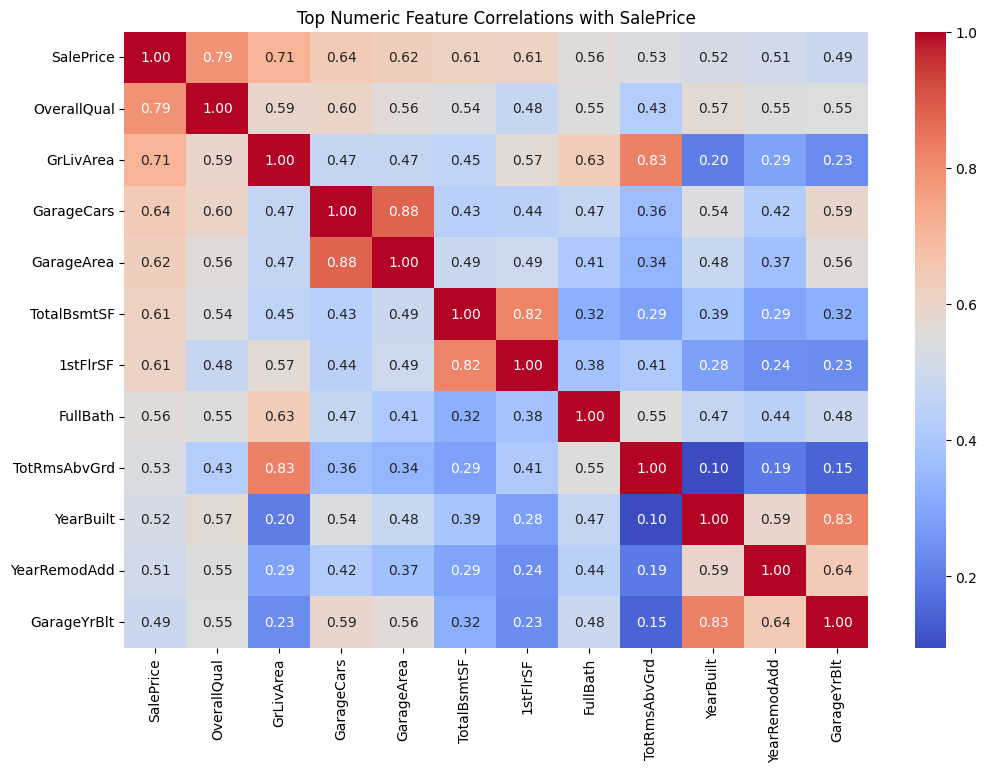

,SalePrice
SalePrice,1.000000
OverallQual,0.790982
GrLivArea,0.708624
GarageCars,0.640409
GarageArea,0.623431
TotalBsmtSF,0.613581
1stFlrSF,0.605852
FullBath,0.560664
TotRmsAbvGrd,0.533723
YearBuilt,0.522897


In [44]:
numeric_df = df.select_dtypes(include=np.number)

corr = numeric_df.corr(numeric_only=True)

plt.figure(figsize=(12, 8))
top_corr_features = corr["SalePrice"].abs().sort_values(ascending=False).head(12).index
sns.heatmap(df[top_corr_features].corr(numeric_only=True), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Top Numeric Feature Correlations with SalePrice")
plt.show()

corr["SalePrice"].sort_values(ascending=False).head(15)

# 7. Feature Engineering

Feature engineering means creating useful new columns from existing columns.

For a house price model, useful engineered features may include:

- house age
- years since remodel
- total square footage
- total bathrooms
- whether the house has a garage
- whether the house has a basement

These features help the model see patterns more clearly.

In [45]:
def add_house_features(data):
    data = data.copy()

    if "YrSold" in data.columns and "YearBuilt" in data.columns:
        data["HouseAge"] = data["YrSold"] - data["YearBuilt"]
    elif "YearBuilt" in data.columns:
        data["HouseAge"] = 2026 - data["YearBuilt"]

    if "YrSold" in data.columns and "YearRemodAdd" in data.columns:
        data["RemodAge"] = data["YrSold"] - data["YearRemodAdd"]
    elif "YearRemodAdd" in data.columns:
        data["RemodAge"] = 2026 - data["YearRemodAdd"]

    square_foot_cols = [col for col in ["TotalBsmtSF", "1stFlrSF", "2ndFlrSF"] if col in data.columns]
    if square_foot_cols:
        data["TotalSF"] = data[square_foot_cols].sum(axis=1)

    if any(col in data.columns for col in ["FullBath", "HalfBath", "BsmtFullBath", "BsmtHalfBath"]):
        data["TotalBath"] = 0
        if "FullBath" in data.columns:
            data["TotalBath"] += data["FullBath"]
        if "HalfBath" in data.columns:
            data["TotalBath"] += 0.5 * data["HalfBath"]
        if "BsmtFullBath" in data.columns:
            data["TotalBath"] += data["BsmtFullBath"]
        if "BsmtHalfBath" in data.columns:
            data["TotalBath"] += 0.5 * data["BsmtHalfBath"]

    if "GarageArea" in data.columns:
        data["HasGarage"] = np.where(data["GarageArea"].fillna(0) > 0, "Yes", "No")

    if "TotalBsmtSF" in data.columns:
        data["HasBasement"] = np.where(data["TotalBsmtSF"].fillna(0) > 0, "Yes", "No")

    return data


df_fe = add_house_features(df)

print("Original shape:", df.shape)
print("After feature engineering:", df_fe.shape)

new_cols = [col for col in ["HouseAge", "RemodAge", "TotalSF", "TotalBath", "HasGarage", "HasBasement"] if col in df_fe.columns]
df_fe[new_cols].head()

Original shape: (1460, 81)
After feature engineering: (1460, 87)


,HouseAge,RemodAge,TotalSF,TotalBath,HasGarage,HasBasement
0,5,5,2566,3.5,Yes,Yes
1,31,31,2524,2.5,Yes,Yes
2,7,6,2706,3.5,Yes,Yes
3,91,36,2473,2.0,Yes,Yes
4,8,8,3343,3.5,Yes,Yes


# 8. Prepare Data for Machine Learning

We now prepare:

- `X` = features used for prediction
- `y` = target variable we want to predict

For the web app, we intentionally use a manageable set of features so the app is easier for students to understand and demonstrate.

In [46]:
target = "SalePrice"

candidate_numeric_features = [
    "OverallQual",
    "GrLivArea",
    "GarageCars",
    "GarageArea",
    "TotalBsmtSF",
    "1stFlrSF",
    "FullBath",
    "TotRmsAbvGrd",
    "YearBuilt",
    "YearRemodAdd",
    "LotArea",
    "HouseAge",
    "RemodAge",
    "TotalSF",
    "TotalBath"
]

candidate_categorical_features = [
    "Neighborhood",
    "HouseStyle",
    "ExterQual",
    "KitchenQual",
    "BsmtQual",
    "GarageType",
    "SaleCondition",
    "HasGarage",
    "HasBasement"
]

numeric_features = [col for col in candidate_numeric_features if col in df_fe.columns]
categorical_features = [col for col in candidate_categorical_features if col in df_fe.columns]

features = numeric_features + categorical_features

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)
print("Total selected features:", len(features))

X = df_fe[features]
y = df_fe[target]

X.head()

Numeric features: ['OverallQual', 'GrLivArea', 'GarageCars', 'GarageArea', 'TotalBsmtSF', '1stFlrSF', 'FullBath', 'TotRmsAbvGrd', 'YearBuilt', 'YearRemodAdd', 'LotArea', 'HouseAge', 'RemodAge', 'TotalSF', 'TotalBath']
Categorical features: ['Neighborhood', 'HouseStyle', 'ExterQual', 'KitchenQual', 'BsmtQual', 'GarageType', 'SaleCondition', 'HasGarage', 'HasBasement']
Total selected features: 24


,OverallQual,GrLivArea,GarageCars,GarageArea,TotalBsmtSF,1stFlrSF,FullBath,TotRmsAbvGrd,YearBuilt,YearRemodAdd,...,TotalBath,Neighborhood,HouseStyle,ExterQual,KitchenQual,BsmtQual,GarageType,SaleCondition,HasGarage,HasBasement
0,7,1710,2,548,856,856,2,8,2003,2003,...,3.5,CollgCr,2Story,Gd,Gd,Gd,Attchd,Normal,Yes,Yes
1,6,1262,2,460,1262,1262,2,6,1976,1976,...,2.5,Veenker,1Story,TA,TA,Gd,Attchd,Normal,Yes,Yes
2,7,1786,2,608,920,920,2,6,2001,2002,...,3.5,CollgCr,2Story,Gd,Gd,Gd,Attchd,Normal,Yes,Yes
3,7,1717,3,642,756,961,1,7,1915,1970,...,2.0,Crawfor,2Story,TA,Gd,TA,Detchd,Abnorml,Yes,Yes
4,8,2198,3,836,1145,1145,2,9,2000,2000,...,3.5,NoRidge,2Story,Gd,Gd,Gd,Attchd,Normal,Yes,Yes


# 9. Train/Test Split

We split the data into:

- training data — used to teach the model
- testing data — used to check how well the model performs on unseen data

This helps us avoid judging the model only on data it already learned from.

In [47]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (1168, 24)
X_test shape: (292, 24)
y_train shape: (1168,)
y_test shape: (292,)


# 10. Build a Preprocessing Pipeline

Machine learning models need clean numeric inputs.

Our pipeline will:

## For numeric columns

- fill missing values using the median
- scale values using `StandardScaler`

## For categorical columns

- fill missing values using the most frequent value
- convert categories into numbers using `OneHotEncoder`

This is better than manually cleaning training and test data separately.

In [48]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

print("Preprocessing pipeline created ✅")

Preprocessing pipeline created ✅


# 11. Train Multiple Regression Models

We will compare several models:

1. Linear Regression  
2. Ridge Regression  
3. Random Forest Regressor  
4. Gradient Boosting Regressor  

For a live demo, this helps students see that different models can produce different results.

In [49]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Random Forest": RandomForestRegressor(n_estimators=200, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42)
}

results = []
trained_pipelines = {}

for model_name, model in models.items():
    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipeline.fit(X_train, y_train)
    predictions = pipeline.predict(X_test)

    mae = mean_absolute_error(y_test, predictions)
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    r2 = r2_score(y_test, predictions)

    results.append({
        "model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })

    trained_pipelines[model_name] = pipeline

results_df = pd.DataFrame(results).sort_values("RMSE")
results_df

,model,MAE,RMSE,R2
3,Gradient Boosting,17173.116437,25753.764204,0.913530
2,Random Forest,18139.103333,30885.105870,0.875639
1,Ridge Regression,20475.588537,33203.823456,0.856265
0,Linear Regression,20475.602484,33217.591602,0.856146


# 12. Interpret the Evaluation Metrics

## MAE — Mean Absolute Error

The average size of the model's error.

If MAE is 20,000, the model is off by about 20,000 dollars on average.

## RMSE — Root Mean Squared Error

Also measures error, but punishes large mistakes more strongly.

## R² Score

Shows how much variation in sale price the model explains.

Closer to 1 is better.

However, a high score does not automatically mean the model is safe, fair, or ready for real-world use.

In [50]:
best_model_name = results_df.iloc[0]["model"]
best_pipeline = trained_pipelines[best_model_name]

print("Best model based on lowest RMSE:", best_model_name)
print(results_df.iloc[0])

Best model based on lowest RMSE: Gradient Boosting
model    Gradient Boosting
MAE           17173.116437
RMSE          25753.764204
R2                 0.91353
Name: 3, dtype: object


# 13. Visualize Model Predictions

We now compare actual sale prices with predicted sale prices.

A strong model should have predictions close to the diagonal pattern.

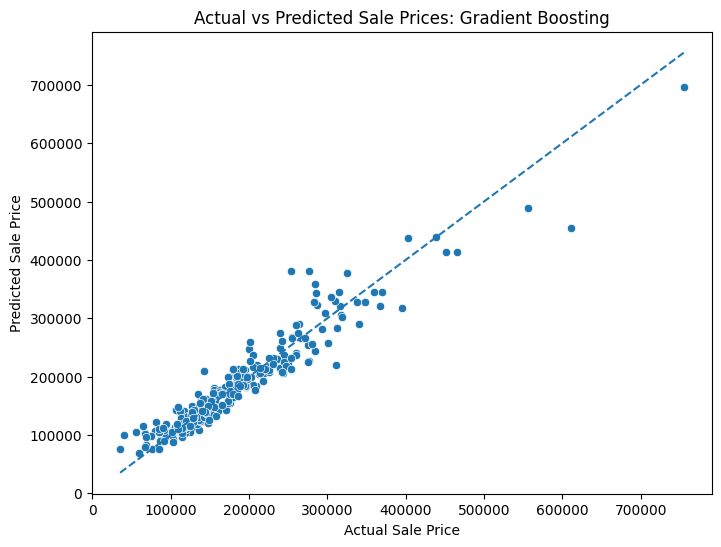

In [51]:
best_predictions = best_pipeline.predict(X_test)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=best_predictions)
plt.xlabel("Actual Sale Price")
plt.ylabel("Predicted Sale Price")
plt.title(f"Actual vs Predicted Sale Prices: {best_model_name}")

min_price = min(y_test.min(), best_predictions.min())
max_price = max(y_test.max(), best_predictions.max())
plt.plot([min_price, max_price], [min_price, max_price], linestyle="--")

plt.show()

# 14. Residual Analysis

A residual is the difference between the actual value and the predicted value.

`residual = actual price - predicted price`

Residual plots help us see where the model makes bigger mistakes.

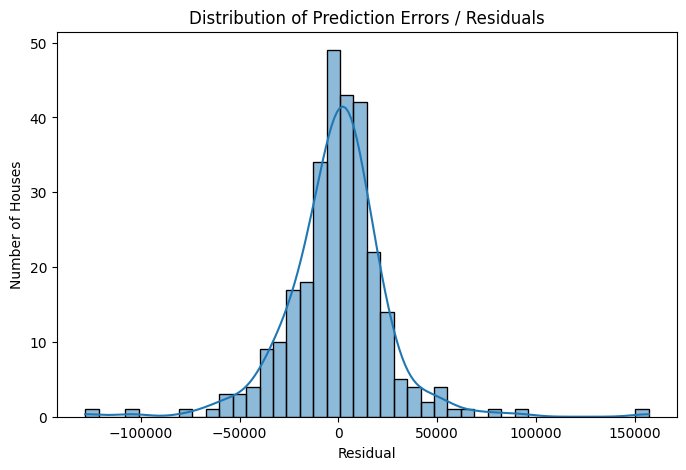

Average residual: -686.67
Median residual: 65.67


In [52]:
residuals = y_test - best_predictions

plt.figure(figsize=(8, 5))
sns.histplot(residuals, kde=True)
plt.title("Distribution of Prediction Errors / Residuals")
plt.xlabel("Residual")
plt.ylabel("Number of Houses")
plt.show()

print("Average residual:", round(residuals.mean(), 2))
print("Median residual:", round(residuals.median(), 2))

# 15. Feature Importance

For tree-based models such as Random Forest and Gradient Boosting, we can inspect which transformed features were influential.

This helps us explain the model, but we must be careful:

- feature importance does not prove causation
- it can be affected by correlations
- it should be interpreted together with business knowledge

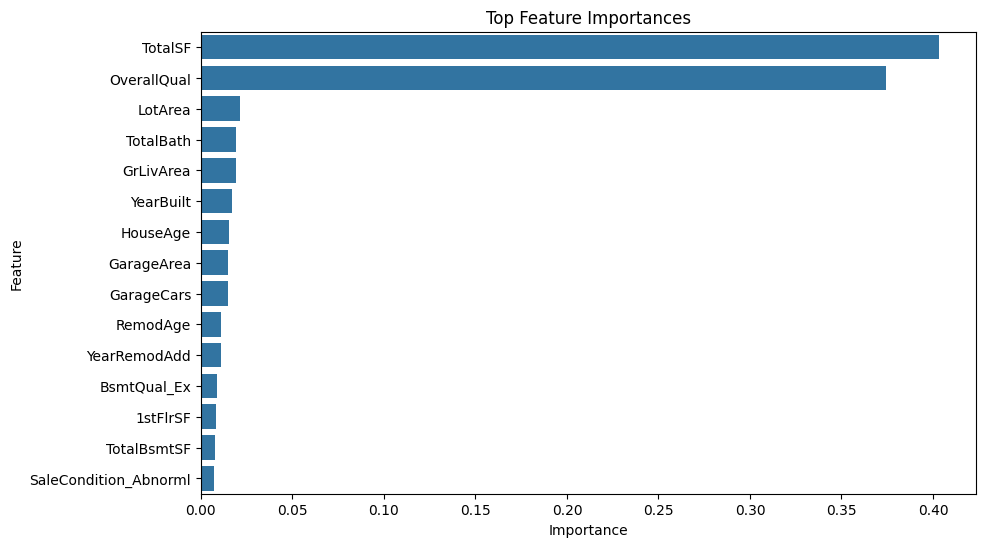

,feature,importance
13,TotalSF,0.403288
0,OverallQual,0.374159
10,LotArea,0.021124
14,TotalBath,0.019163
1,GrLivArea,0.019080
8,YearBuilt,0.016726
11,HouseAge,0.015500
3,GarageArea,0.014938
2,GarageCars,0.014904
12,RemodAge,0.010925


In [53]:
def show_feature_importance(pipeline, top_n=20):
    model = pipeline.named_steps["model"]

    if not hasattr(model, "feature_importances_"):
        print("This model does not provide feature_importances_. Try Random Forest or Gradient Boosting.")
        return None

    preprocessor_fitted = pipeline.named_steps["preprocessor"]

    feature_names = []

    if numeric_features:
        feature_names.extend(numeric_features)

    if categorical_features:
        encoder = preprocessor_fitted.named_transformers_["cat"].named_steps["encoder"]
        encoded_names = encoder.get_feature_names_out(categorical_features)
        feature_names.extend(encoded_names)

    importance_df = pd.DataFrame({
        "feature": feature_names,
        "importance": model.feature_importances_
    }).sort_values("importance", ascending=False)

    plt.figure(figsize=(10, 6))
    sns.barplot(data=importance_df.head(top_n), x="importance", y="feature")
    plt.title("Top Feature Importances")
    plt.xlabel("Importance")
    plt.ylabel("Feature")
    plt.show()

    return importance_df


tree_model_name = "Random Forest" if "Random Forest" in trained_pipelines else best_model_name
importance_df = show_feature_importance(trained_pipelines[tree_model_name], top_n=15)

if importance_df is not None:
    display(importance_df.head(15))

# 16. Make a Single Prediction

This is the bridge between the notebook and the future web app.

We will create one example house and ask the model to estimate its sale price.

In [54]:
example_house = X_test.iloc[[0]].copy()

predicted_price = best_pipeline.predict(example_house)[0]

print("Example house features:")
display(example_house)

print(f"Predicted sale price: ${predicted_price:,.2f}")
print(f"Actual sale price:    ${y_test.iloc[0]:,.2f}")

Example house features:


,OverallQual,GrLivArea,GarageCars,GarageArea,TotalBsmtSF,1stFlrSF,FullBath,TotRmsAbvGrd,YearBuilt,YearRemodAdd,...,TotalBath,Neighborhood,HouseStyle,ExterQual,KitchenQual,BsmtQual,GarageType,SaleCondition,HasGarage,HasBasement
892,6,1068,1,264,1059,1068,1,6,1963,2003,...,1.5,Sawyer,1Story,TA,TA,TA,Attchd,Normal,Yes,Yes


Predicted sale price: $139,379.98
Actual sale price:    $154,500.00


# 17. Business Interpretation

A model is not useful until we explain it in business language.

Example explanation:

> The model estimates house price using property quality, living area, garage capacity, basement size, age, and neighborhood information. In this demonstration, the best model was selected based on the lowest RMSE on the test set. The prediction should be treated as an estimate, not a final valuation.

## Risks and limitations

- The data comes from a specific market and time period.
- The model may not work well in another city or country without retraining.
- Missing or incorrect inputs can produce poor predictions.
- Housing prices are affected by economic conditions that may not appear in the dataset.
- The model should support human judgment, not replace it.

# 18. Save the Final Model

To use the model inside a Streamlit app, we must save:

1. the trained pipeline  
2. the metadata needed by the app, such as feature names and dropdown options  

After running this cell, you should see files such as:

- `house_price_model_pipeline.pkl`
- `house_price_app_metadata.pkl`

In [55]:
final_model_name = "Random Forest" if "Random Forest" in trained_pipelines else best_model_name
final_pipeline = trained_pipelines[final_model_name]

metadata = {
    "model_name": final_model_name,
    "numeric_features": numeric_features,
    "categorical_features": categorical_features,
    "features": features,
    "data_source": data_source,
    "categorical_options": {
        col: sorted([str(x) for x in df_fe[col].dropna().unique().tolist()])
        for col in categorical_features
    },
    "numeric_defaults": {
        col: float(df_fe[col].median()) if pd.api.types.is_numeric_dtype(df_fe[col]) else 0
        for col in numeric_features
    }
}

joblib.dump(final_pipeline, "house_price_model_pipeline.pkl")
joblib.dump(metadata, "house_price_app_metadata.pkl")

print("Saved final model:", final_model_name)
print("Files created ✅")
print("- house_price_model_pipeline.pkl")
print("- house_price_app_metadata.pkl")

Saved final model: Random Forest
Files created ✅
- house_price_model_pipeline.pkl
- house_price_app_metadata.pkl


# 19. Build the Streamlit App from Inside the Notebook

This cell creates a file called `app.py`.

The app will:

- load the saved model
- display a product title
- ask the user for house details
- predict the sale price
- display the result in a business-friendly way

After running this cell, download the generated files and place them in a GitHub repository for Streamlit deployment.

In [56]:
app_code = r'''import streamlit as st
import pandas as pd
import joblib

st.set_page_config(
    page_title="HomeValue AI",
    page_icon="🏠",
    layout="centered"
)

st.title("🏠 HomeValue AI")
st.subheader("House Price Prediction Demo App")

st.write(
    """
    This app estimates a house sale price using a machine learning model trained
    on housing data. It is a learning prototype and should not replace a professional valuation.
    """
)

MODEL_PATH = "house_price_model_pipeline.pkl"
METADATA_PATH = "house_price_app_metadata.pkl"


@st.cache_resource
def load_artifacts():
    model = joblib.load(MODEL_PATH)
    metadata = joblib.load(METADATA_PATH)
    return model, metadata


try:
    model, metadata = load_artifacts()
except FileNotFoundError:
    st.error(
        "Model files not found. Please run the notebook first to generate "
        "`house_price_model_pipeline.pkl` and `house_price_app_metadata.pkl`, "
        "then place them in the same folder as this app."
    )
    st.stop()


numeric_features = metadata["numeric_features"]
categorical_features = metadata["categorical_features"]
categorical_options = metadata["categorical_options"]
numeric_defaults = metadata["numeric_defaults"]


st.sidebar.header("Enter House Details")

user_input = {}


for feature in numeric_features:
    default_value = numeric_defaults.get(feature, 0)

    if "Year" in feature:
        value = st.sidebar.number_input(
            feature,
            min_value=1800,
            max_value=2030,
            value=int(default_value),
            step=1
        )

    elif feature == "OverallQual":
        value = st.sidebar.slider(
            feature,
            min_value=1,
            max_value=10,
            value=int(round(default_value))
        )

    else:
        value = st.sidebar.number_input(
            feature,
            min_value=0.0,
            value=float(default_value),
            step=100.0
        )

    user_input[feature] = value


for feature in categorical_features:
    options = categorical_options.get(feature, [])

    if not options:
        options = ["Unknown"]

    value = st.sidebar.selectbox(
        feature,
        options=options
    )

    user_input[feature] = value


input_df = pd.DataFrame([user_input])

st.write("### Input Summary")
st.dataframe(input_df)


if st.button("Predict House Price"):
    try:
        prediction = model.predict(input_df)[0]

        st.success(f"Estimated Sale Price: ${prediction:,.2f}")

        lower_bound = prediction * 0.90
        upper_bound = prediction * 1.10

        st.info(
            f"Suggested interpretation range: "
            f"${lower_bound:,.2f} to ${upper_bound:,.2f}. "
            "This range is only a simple uncertainty guide for demo purposes."
        )

        st.write("### Business Interpretation")

        st.write(
            """
            The model uses property characteristics such as quality, size, garage
            information, age, and location-related features to estimate a likely
            sale price.

            A real business should validate the model using current local market
            data before using it.
            """
        )

    except Exception as error:
        st.error(f"Prediction failed: {error}")


st.write("---")

st.caption(
    "HomeValue AI is a teaching demo for Data Science, Machine Learning, "
    "and Streamlit deployment."
)
'''

with open("app.py", "w", encoding="utf-8") as f:
    f.write(app_code)

print("app.py created successfully ✅")


app.py created successfully ✅


# 20. Create `requirements.txt`

Streamlit needs a dependency file so that the deployment platform knows what packages to install.

This cell creates a simple `requirements.txt`.

In [60]:
requirements = """streamlit
pandas
numpy
scikit-learn==1.5.2
joblib
matplotlib
seaborn
"""

with open("requirements.txt", "w", encoding="utf-8") as f:
    f.write(requirements)

print("requirements.txt created successfully ✅")
print(requirements)

requirements.txt created successfully ✅
streamlit
pandas
numpy
scikit-learn==1.5.2
joblib
matplotlib
seaborn



# 21. Create a README File

A `README.md` explains the project to anyone who opens the GitHub repository.

This is useful for student portfolios.

In [58]:
readme_text = r"""# HomeValue AI: House Price Prediction App

## Project Overview

HomeValue AI is an end-to-end Data Science and Machine Learning demo project.

The project uses housing data to train a regression model that estimates house sale prices from property features.

## Business Use Case

Real estate agents, homeowners, developers, and analysts often need quick property price estimates. This app demonstrates how a machine learning model can support that decision-making process.

## Workflow

1. Load housing dataset
2. Inspect and clean data
3. Perform exploratory data analysis
4. Create visualizations
5. Engineer useful features
6. Train regression models
7. Evaluate model performance
8. Save final model
9. Build Streamlit app
10. Deploy app online

## Files

- `house_price_prediction_end_to_end_live_demo.ipynb` — full notebook workflow
- `app.py` — Streamlit web app
- `requirements.txt` — Python dependencies
- `house_price_model_pipeline.pkl` — saved model generated after running the notebook
- `house_price_app_metadata.pkl` — metadata generated after running the notebook

## Important Note

This app is a teaching prototype. It should not be used as a professional valuation tool without further validation using current local market data.
"""

with open("README.md", "w", encoding="utf-8") as f:
    f.write(readme_text)

print("README.md created successfully ✅")

README.md created successfully ✅


# 22. Deployment Checklist

To deploy this project to Streamlit Community Cloud:

1. Run this notebook fully.
2. Make sure these files exist:
   - `app.py`
   - `requirements.txt`
   - `house_price_model_pipeline.pkl`
   - `house_price_app_metadata.pkl`
   - `README.md`
3. Create a GitHub repository.
4. Upload the files into the repository.
5. Go to Streamlit Community Cloud.
6. Connect your GitHub account.
7. Select the repository.
8. Select `app.py` as the main file.
9. Deploy the app.
10. Share the app link with students.

## Live class demo idea

You can present this as a product launch:

> “Today we are not just writing Python. We are building a small AI-powered real estate product.”

# 23. Final Student Reflection

Answer these questions in markdown:

1. What problem does HomeValue AI solve?
2. What is the target variable?
3. Why is this a regression problem?
4. Which EDA chart helped you understand the data most?
5. Which engineered feature made business sense to you?
6. Which model performed best?
7. Which metric did you use to judge the model?
8. What are two risks of using this model in the real world?
9. How does Streamlit help turn a notebook into a product?
10. What would you improve if this were a real client project?

In [59]:
# Write your final reflection here as comments, or create a markdown cell below.

# 1.
# 2.
# 3.
# 4.
# 5.
# 6.
# 7.
# 8.
# 9.
# 10.

# 🎉 End of Project

Congratulations.

You have walked through a complete project:

**Business problem → Data → EDA → Visualization → Feature Engineering → Machine Learning → Evaluation → Interpretation → Streamlit App**

This is the kind of workflow students can use for portfolio projects, internship preparation, freelance demos, and future AI/Data Science work.